# EDA – Tổng quan dữ liệu và tương quan với giá

Mục tiêu:
- Từ data/unified/raw_merged.csv:
  - Báo số dòng trước khi merge (tổng dòng của các file trong data/extracted) và số dòng sau merge
  - Thống kê giá trị thiếu (per column + số dòng có ít nhất 1 giá trị thiếu)
- Từ data/unified/preprocessed_merged.csv:
  - Tính tương quan Pearson giữa các biến numeric với cột giá (gia)
  - Vẽ heatmap

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)

def find_path(rel):
    # Hỗ trợ chạy từ gốc repo hoặc từ thư mục con (eda/)
    for base in [Path("."), Path("..")]:
        p = (base / rel)
        if p.exists():
            return p
    return Path(rel)

RAW_MERGED = find_path("data/unified/raw_merged.csv")
PRE_MERGED = find_path("data/unified/preprocessed_merged.csv")
EXTRACTED_DIR = find_path("data/extracted")

print("RAW_MERGED:", RAW_MERGED.resolve() if RAW_MERGED.exists() else "Không tìm thấy")
print("PRE_MERGED:", PRE_MERGED.resolve() if PRE_MERGED.exists() else "Không tìm thấy")
print("EXTRACTED_DIR:", EXTRACTED_DIR.resolve() if EXTRACTED_DIR.exists() else "Không tìm thấy")

RAW_MERGED: C:\Users\ADMIN\source\Năm 3 - HK1\Nhập môn KHDL\project\data\unified\raw_merged.csv
PRE_MERGED: C:\Users\ADMIN\source\Năm 3 - HK1\Nhập môn KHDL\project\data\unified\preprocessed_merged.csv
EXTRACTED_DIR: C:\Users\ADMIN\source\Năm 3 - HK1\Nhập môn KHDL\project\data\extracted


## 1) Tổng quan dữ liệu raw (trước và sau merge) + thiếu dữ liệu
- Tổng số dòng trước merge = tổng số dòng của tất cả CSV trong data/extracted
- Số dòng sau merge = số dòng trong data/unified/raw_merged.csv
- Báo cáo thiếu dữ liệu:
  - Số dòng có ít nhất 1 giá trị thiếu
  - Số ô thiếu per column và tỉ lệ thiếu

In [12]:
from pathlib import Path
import pandas as pd
import re

def find_path(rel):
    for base in [Path("."), Path("..")]:
        p = (base / rel)
        if p.exists():
            return p
    return Path(rel)

RAW_MERGED = find_path("data/unified/raw_merged.csv")
PRE_MERGED = find_path("data/unified/preprocessed_merged.csv")

if not RAW_MERGED.exists():
    raise SystemExit("Không tìm thấy data/unified/raw_merged.csv")

# Đọc raw_merged.csv
df_raw = pd.read_csv(
    RAW_MERGED,
    dtype=str,
    encoding="utf-8-sig",
    encoding_errors="ignore",
    on_bad_lines="skip"
)
# Làm sạch header (BOM)
df_raw.columns = [c.replace("\ufeff", "").strip() for c in df_raw.columns]

# Xác định dòng thiếu (coi "", khoảng trắng, na/n/a/none/null/nan là thiếu)
missing_like = re.compile(r"^(?:\s*|na|n/a|none|null|nan)$", flags=re.IGNORECASE)
df_raw_na = df_raw.replace(missing_like, pd.NA, regex=True)

raw_rows = len(df_raw)
raw_rows_with_missing = int(df_raw_na.isna().any(axis=1).sum())

# Đọc preprocessed_merged.csv và đếm dòng còn lại
if not PRE_MERGED.exists():
    raise SystemExit("Không tìm thấy data/unified/preprocessed_merged.csv")

df_pre = pd.read_csv(
    PRE_MERGED,
    encoding="utf-8-sig",
    encoding_errors="ignore",
    on_bad_lines="skip"
)
print(df_pre.dtypes)
df_pre.columns = [c.replace("\ufeff", "").strip() for c in df_pre.columns]
pre_rows = len(df_pre)

print("=== Summary ===")
print(f"- raw_merged.csv: {raw_rows:,} dòng")
print(f"- Số dòng có ít nhất 1 giá trị thiếu (raw): {raw_rows_with_missing:,} dòng")
print(f"- preprocessed_merged.csv: {pre_rows:,} dòng")

# Bảng tóm tắt gọn
summary_df = pd.DataFrame({
    "metric": [
        "raw_rows_total",
        "raw_rows_with_any_missing",
        "preprocessed_rows_total"
    ],
    "value": [raw_rows, raw_rows_with_missing, pre_rows]
})
try:
    display(summary_df)
except:
    print(summary_df)
df_pre.describe()

tieu_de           object
gia              float64
dia_chi           object
dien_tich_dat    float64
phong_ngu        float64
phong_tam        float64
so_tang          float64
phap_ly           object
ngay_dang         object
dtype: object
=== Summary ===
- raw_merged.csv: 10,355 dòng
- Số dòng có ít nhất 1 giá trị thiếu (raw): 3,200 dòng
- preprocessed_merged.csv: 7,006 dòng


,metric,value
0,raw_rows_total,10355
1,raw_rows_with_any_missing,3200
2,preprocessed_rows_total,7006


,gia,dien_tich_dat,phong_ngu,phong_tam,so_tang
count,6974.000000,7006.000000,7006.000000,7006.000000,7006.000000
mean,25.761966,75.203260,4.798173,4.734085,6.013845
std,246.577111,124.824033,4.857963,4.832580,117.210638
min,0.014000,1.500000,1.000000,1.000000,1.000000
25%,6.400000,38.000000,3.000000,3.000000,3.000000
50%,9.300000,54.000000,4.000000,4.000000,4.000000
75%,17.560000,80.000000,5.000000,5.000000,5.000000
max,9400.000000,6117.000000,100.000000,101.000000,9810.000000


Cột giá sử dụng: gia


,corr_with_price
dien_tich_dat,0.038216
phong_tam,0.020790
phong_ngu,0.013806
so_tang,0.001476


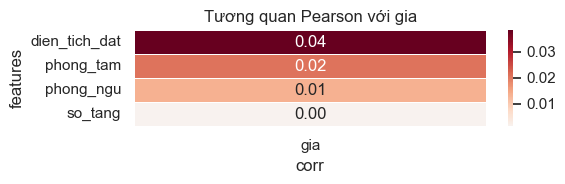

In [3]:
if not PRE_MERGED.exists():
    raise SystemExit("Không tìm thấy data/unified/preprocessed_merged.csv")

dfp = pd.read_csv(PRE_MERGED, encoding="utf-8-sig", encoding_errors="ignore", on_bad_lines="skip")
dfp.columns = [c.replace("\ufeff", "").strip() for c in dfp.columns]

# Xác định cột giá (ưu tiên 'gia')
target_cands = ["gia", "price_vnd", "price_value", "price"]
target = next((c for c in target_cands if c in dfp.columns), None)
if target is None:
    raise SystemExit(f"Không tìm thấy cột giá trong {target_cands}")

# Ép giá về số
dfp[target] = pd.to_numeric(dfp[target], errors="coerce")

# Chọn các cột numeric khác
ban_cols = {"listing_id","url","site","tieu_de","title","mo_ta","description","dia_chi","address",
            "phap_ly","legal","posted_at","posted_at_raw","ngay_dang"}
candidates = [c for c in dfp.columns if c not in ban_cols | {target}]

num_cols = []
for c in candidates:
    tmp = pd.to_numeric(dfp[c], errors="coerce")
    ratio_numeric = tmp.notna().mean()
    if ratio_numeric >= 0.6 and tmp.notna().sum() > 0:
        dfp[c] = tmp
        num_cols.append(c)

if not num_cols:
    raise SystemExit("Không tìm thấy biến numeric đủ điều kiện (>=60% giá trị số).")

# Chuẩn bị dataframe chỉ gồm target + numeric cols, loại NA ở target
dfn = dfp[[target] + num_cols].dropna(subset=[target])

# Tính tương quan Pearson
corr_full = dfn.corr(numeric_only=True)
corr_with_target = corr_full[target].drop(index=target).sort_values(key=lambda s: s.abs(), ascending=False)

print(f"Cột giá sử dụng: {target}")
display(corr_with_target.to_frame("corr_with_price"))

# Heatmap tương quan với giá (1 cột)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(6, max(2, 0.4*len(corr_with_target))))
sns.heatmap(
    corr_with_target.to_frame(),
    annot=True, fmt=".2f", cmap="RdBu_r", center=0,
    cbar=True, linewidths=0.5
)
plt.title(f"Tương quan Pearson với {target}")
plt.xlabel("corr")
plt.ylabel("features")
plt.tight_layout()
plt.show()

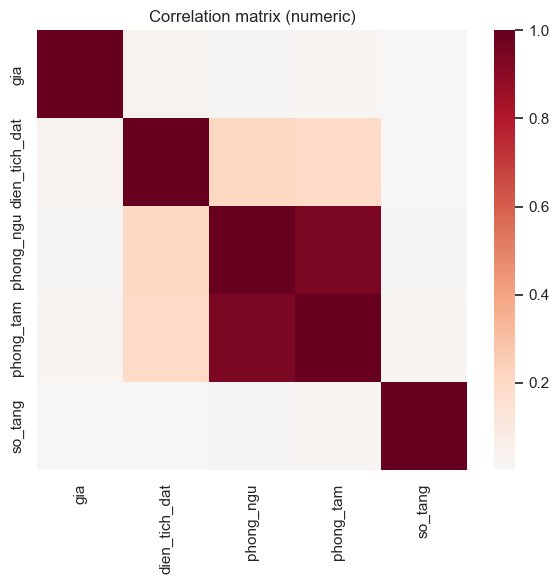

In [4]:
plt.figure(figsize=(min(12, 1.2*len(corr_full.columns)), min(10, 1.2*len(corr_full.columns))))
sns.heatmap(corr_full, annot=False, cmap="RdBu_r", center=0, cbar=True)
plt.title("Correlation matrix (numeric)")
plt.tight_layout()
plt.show()